# Pulmonology benchmark — visual analytics

This notebook complements `infereval describe` with the kind of visual analysis a text-based CLI can't do. It uses the bundled pulmonary-edema benchmark (`examples/pulmonary_edema/benchmark.json`) and the six cross-family evaluation files committed alongside it (`experiments/results/pulmonology/`).

> **Caveat (carried from the source files).** The pulmonary benchmark's analyst verdicts are *placeholder guesses* authored without clinical credentials — the planned study replaces them with a real pulmonologist's labels. The κ numbers below describe the *framework producing coherent values*, not model agreement with a real expert. See `examples/pulmonary_edema/README.md` and `experiments/results/pulmonology_2026-05-19.md` for the full caveat.

## Dependencies

Beyond `infereval` itself, this notebook uses `matplotlib`, `pandas`, and `numpy`. Install once:

```bash
pip install matplotlib pandas
```

## Outline

1. **Benchmark structure** — bearer co-occurrence in premises, premise-set sizes, verdict distribution per target, RSR-target groupings.
2. **Cross-model evaluation** — κ_C bar chart, coverage / κ_C scatter, item × model verdict heatmap, pairwise Cohen κ matrix.
3. **What jumps out** — the visual answer to a few questions the CLI cannot.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations

import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from infereval.benchmark import Benchmark
from infereval.evaluation import Evaluation
from infereval.metrics import cohens_kappa, fleiss_kappa, consensus_reference

# All paths are repo-relative so this runs from anywhere by adjusting REPO_ROOT.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'examples' / 'pulmonary_edema').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

BENCH_PATH = REPO_ROOT / 'examples' / 'pulmonary_edema' / 'benchmark.json'
RESULTS_DIR = REPO_ROOT / 'experiments' / 'results' / 'pulmonology'

bench = Benchmark.load(BENCH_PATH)
print(f'Benchmark: {bench.id}')
print(f'  |B|={len(bench.bearers)}  n={bench.n}  m={bench.m}')

MODELS = [
    ('GPT-4.1',         'gpt-4.1'),
    ('GPT-5.5',         'gpt-5.5'),
    ('Claude Opus 4.7', 'claude-opus-4.7'),
    ('Gemini 2.5 Pro',  'gemini-2.5-pro'),
    ('DeepSeek v4-pro', 'deepseek-v4-pro'),
    ('Qwen3-max',       'qwen3-max'),
]
evals = {label: Evaluation.load(RESULTS_DIR / f'{slug}-eta.json') for label, slug in MODELS}
print(f'Loaded {len(evals)} evaluations')

Benchmark: pulmonary-edema-differential-v0.1
  |B|=20  n=29  m=1
Loaded 6 evaluations


## 1. Benchmark structure

### 1.1 Bearer co-occurrence in premises

A heatmap of how often each pair of bearers appears together as premises across the 29 items. Bearers that always co-occur form the methodology's *clusters* — informally, the conditions of an inferential context. Bearers that never co-occur tell you which independent dimensions the benchmark probes.

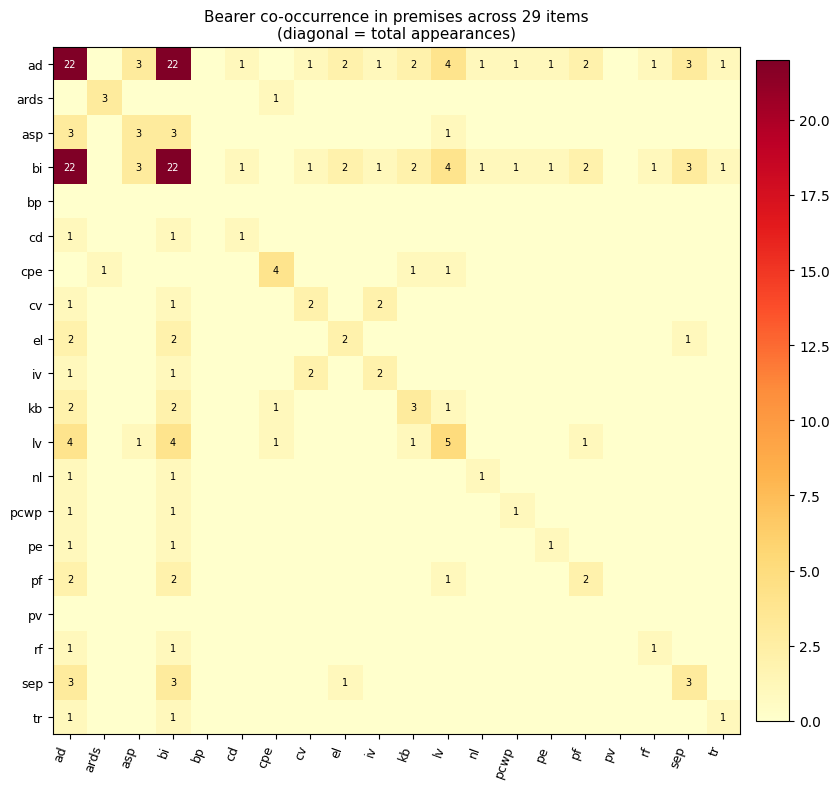

In [2]:
bearer_ids = sorted(bench.bearers)
n_bearers = len(bearer_ids)
id_to_idx = {b: i for i, b in enumerate(bearer_ids)}

cooc = np.zeros((n_bearers, n_bearers), dtype=int)
for item in bench.items:
    for a, b in combinations(item.premises, 2):
        i, j = id_to_idx[a], id_to_idx[b]
        cooc[i, j] += 1
        cooc[j, i] += 1
    # Mark each bearer's own occurrence count on the diagonal.
    for a in item.premises:
        cooc[id_to_idx[a], id_to_idx[a]] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cooc, cmap='YlOrRd', aspect='equal')
ax.set_xticks(range(n_bearers))
ax.set_yticks(range(n_bearers))
ax.set_xticklabels(bearer_ids, rotation=70, ha='right', fontsize=9)
ax.set_yticklabels(bearer_ids, fontsize=9)
ax.set_title('Bearer co-occurrence in premises across 29 items\n(diagonal = total appearances)', fontsize=11)
for i in range(n_bearers):
    for j in range(n_bearers):
        if cooc[i, j] > 0:
            ax.text(j, i, cooc[i, j], ha='center', va='center',
                    color='white' if cooc[i, j] > cooc.max() * 0.6 else 'black',
                    fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()

**Reads.** `bi` and `ad` (bilateral infiltrates, acute dyspnea) dominate the diagonal — they're the *base-case bearers* present in essentially every T1/T2 item. The asymmetric off-diagonal cells highlight which side-premises probe each target: `pf` / `sep` / `asp` / `tr` cluster with `bi`/`ad` (T2 — ARDS context), while `el` / `lv` / `kb` / `pcwp` cluster the same way for T1 (cardiogenic). The cross-cutting items (x-series) light up bearers paired with `cpe` or `ards` directly, which is what gives the methodology its consequence-vs-marker decomposition.

### 1.2 Premise-set size histogram

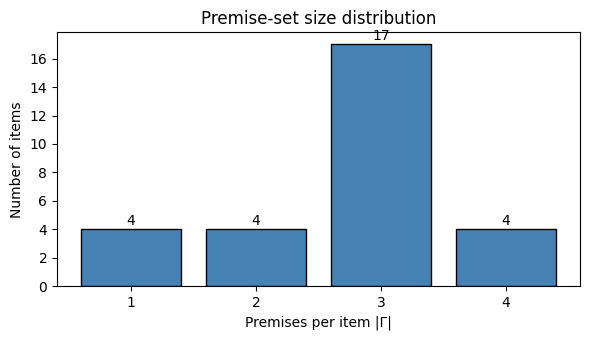

In [3]:
sizes = Counter(len(item.premises) for item in bench.items)
sizes_df = pd.DataFrame(sorted(sizes.items()), columns=['premise_count', 'n_items'])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(sizes_df['premise_count'], sizes_df['n_items'], color='steelblue', edgecolor='black')
for x, y in zip(sizes_df['premise_count'], sizes_df['n_items']):
    ax.text(x, y + 0.3, str(y), ha='center', fontsize=10)
ax.set_xlabel('Premises per item |Γ|')
ax.set_ylabel('Number of items')
ax.set_title('Premise-set size distribution')
ax.set_xticks(sorted(sizes))
plt.tight_layout()
plt.show()

Most items have 2-3 premises — the methodology probes RSR around a 2-bearer target by adding one or two side premises (supporters or defeaters). The few 4-premise items are the `mixed-evidence` / `dialectical-high` cases (e.g. a8, a10, c10) where supporting and defeating evidence coexist.

### 1.3 Verdict distribution per target inference

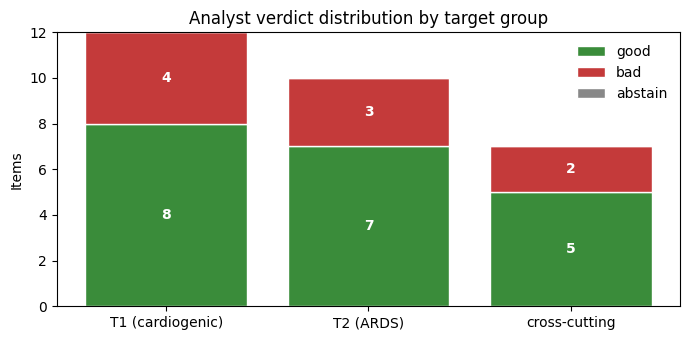

In [4]:
def category_of(item):
    for t in item.tags:
        if len(t) >= 2 and t[0] == 'T' and t[1:].isdigit():
            return t
        if t == 'cross-cutting':
            return t
    return '(other)'

groups = {}
for item in bench.items:
    cat = category_of(item)
    groups.setdefault(cat, Counter())[item.analyst_verdicts[0]] += 1

order = ['T1', 'T2', 'cross-cutting']
verdicts = ['good', 'bad', 'abstain']
colors = {'good': '#3a8c3a', 'bad': '#c43a3a', 'abstain': '#888888'}

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(order))
bottom = np.zeros(len(order))
for v in verdicts:
    heights = [groups.get(g, Counter())[v] for g in order]
    ax.bar(x, heights, bottom=bottom, label=v, color=colors[v], edgecolor='white', linewidth=1)
    for xi, h, b in zip(x, heights, bottom):
        if h > 0:
            ax.text(xi, b + h/2, str(h), ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += heights
ax.set_xticks(x)
ax.set_xticklabels(['T1 (cardiogenic)', 'T2 (ARDS)', 'cross-cutting'])
ax.set_ylabel('Items')
ax.set_title('Analyst verdict distribution by target group')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

T1 and T2 are roughly balanced (8/4 and 7/3 good/bad). The cross-cutting block is 5/2. No abstain labels in this benchmark — the placeholder analyst always commits.

## 2. Cross-model evaluation

### 2.1 Headline metrics — κ_C, κ_F, coverage

In [5]:
summary = []
for label, eta in evals.items():
    abst = sum(1 for it in eta.items if it.model_verdict == 'abstain')
    summary.append({
        'model': label,
        'coverage': 1 - abst / eta.n,
        'kappa_C': cohens_kappa(eta, consensus_reference(eta)),
        'kappa_F': fleiss_kappa(eta),
        'agreement': sum(1 for it in eta.items if it.model_verdict == it.analyst_verdicts[0]) / eta.n,
    })
df = pd.DataFrame(summary).set_index('model').sort_values('kappa_C', ascending=True)
df

,coverage,kappa_C,kappa_F,agreement
model,,,,
Claude Opus 4.7,1.000000,0.535469,0.507879,0.758621
DeepSeek v4-pro,1.000000,0.535469,0.507879,0.758621
GPT-4.1,1.000000,0.650602,0.639752,0.827586
GPT-5.5,1.000000,0.712871,0.707071,0.862069
Gemini 2.5 Pro,1.000000,0.778626,0.776062,0.896552
Qwen3-max,0.793103,0.818898,0.817460,0.724138


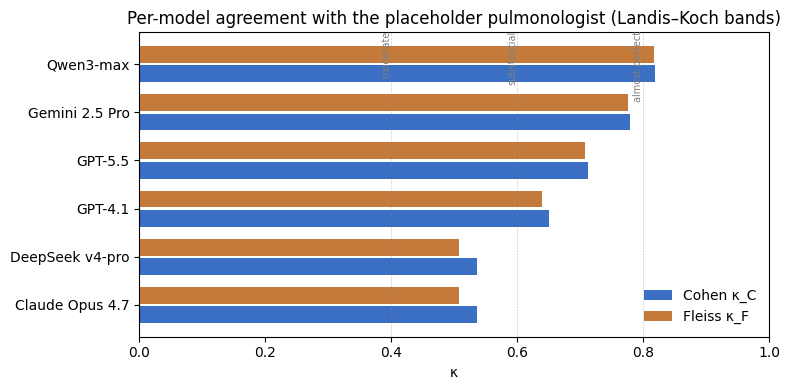

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(df))
ax.barh(y - 0.2, df['kappa_C'], height=0.35, label='Cohen κ_C', color='#3a6fc4')
ax.barh(y + 0.2, df['kappa_F'], height=0.35, label='Fleiss κ_F', color='#c47a3a')
ax.set_yticks(y)
ax.set_yticklabels(df.index)
ax.axvline(0, color='black', linewidth=0.6)
for thresh, name in [(0.4, 'moderate'), (0.6, 'substantial'), (0.8, 'almost perfect')]:
    ax.axvline(thresh, color='grey', linewidth=0.4, linestyle='--', alpha=0.5)
    ax.text(thresh, len(df) - 0.3, name, fontsize=7, rotation=90, va='top', ha='right', color='grey')
ax.set_xlim(0, 1)
ax.set_xlabel('κ')
ax.set_title('Per-model agreement with the placeholder pulmonologist (Landis–Koch bands)')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

Qwen3-max's κ_C is the highest but it's computed over only 23 substantive items — Qwen genuinely uses ABSTAIN on 6 items, which shifts up its κ but drops its raw agreement. The next chart visualizes that tradeoff.

### 2.2 Coverage vs κ_C scatter — the Qwen tradeoff

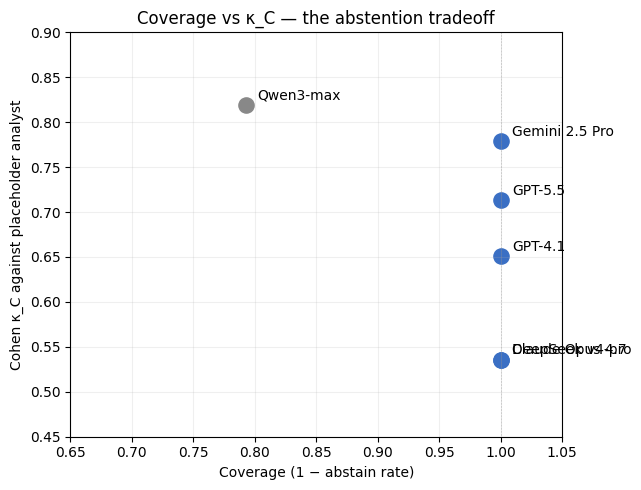

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for label, row in df.iterrows():
    ax.scatter(row['coverage'], row['kappa_C'], s=120,
               color='#888888' if row['coverage'] < 1 else '#3a6fc4')
    ax.annotate(label, (row['coverage'], row['kappa_C']),
                xytext=(8, 4), textcoords='offset points', fontsize=10)
ax.set_xlim(0.65, 1.05)
ax.set_ylim(0.45, 0.9)
ax.axvline(1.0, color='grey', linewidth=0.4, linestyle=':')
ax.set_xlabel('Coverage (1 − abstain rate)')
ax.set_ylabel('Cohen κ_C against placeholder analyst')
ax.set_title('Coverage vs κ_C — the abstention tradeoff')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Qwen3-max sits in the upper-left: highest κ_C of any model on the 23 items it commits on, but lowest coverage because it genuinely uses ABSTAIN. The other five models all sit on the `coverage = 1.0` line; they always commit. This visualization makes the tradeoff legible in a way the numeric table doesn't.

### 2.3 Item × model verdict heatmap

The single most useful cross-model view: each row is an item (ordered by category and id), each column is a model + the analyst, color encodes the verdict. Disagreement clusters jump out visually.

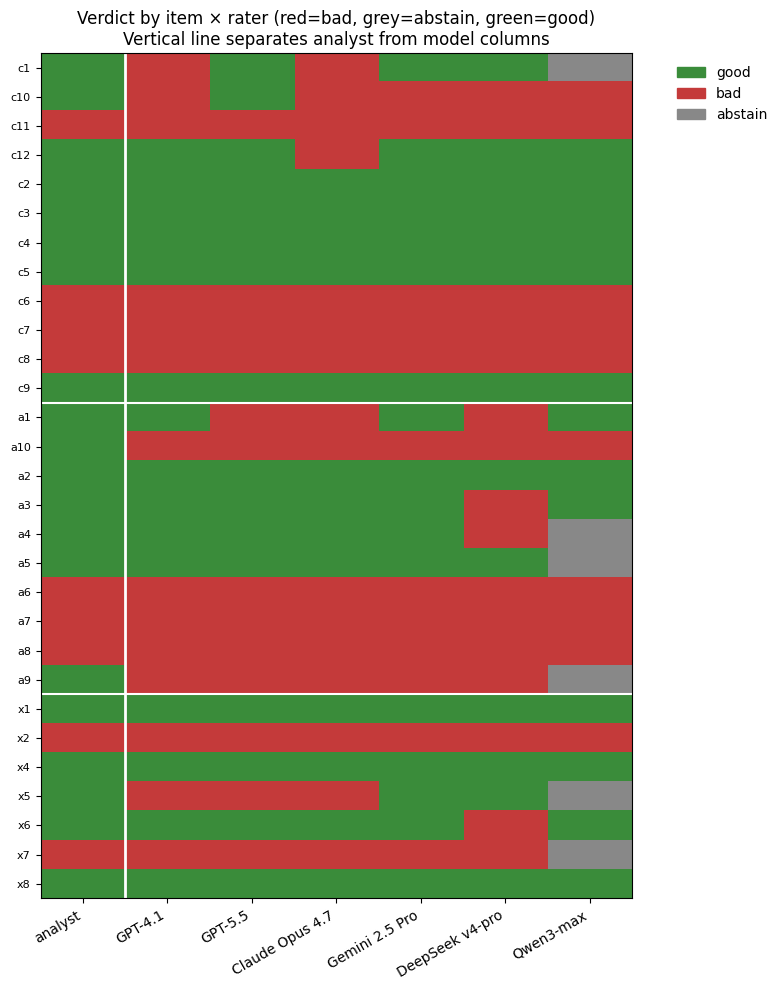

In [8]:
verdict_to_code = {'good': 1, 'abstain': 0, 'bad': -1}
code_to_verdict = {v: k for k, v in verdict_to_code.items()}

# Sort items by category (T1, T2, cross-cutting) and then by id.
def sort_key(item):
    cat = category_of(item)
    cat_order = {'T1': 0, 'T2': 1, 'cross-cutting': 2}.get(cat, 3)
    return (cat_order, item.id)
ordered = sorted(bench.items, key=sort_key)
ids = [it.id for it in ordered]
analyst_col = [verdict_to_code[it.analyst_verdicts[0]] for it in ordered]

matrix = np.zeros((len(ordered), len(MODELS) + 1), dtype=int)
matrix[:, 0] = analyst_col
for col, (label, _) in enumerate(MODELS, start=1):
    eta = evals[label]
    eta_by_id = {it.id: it for it in eta.items}
    matrix[:, col] = [verdict_to_code[eta_by_id[item.id].model_verdict] for item in ordered]

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#c43a3a', '#888888', '#3a8c3a'])  # bad / abstain / good

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(matrix.shape[1]))
ax.set_xticklabels(['analyst'] + [m for m, _ in MODELS], rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(ids)))
ax.set_yticklabels(ids, fontsize=8)
ax.set_title('Verdict by item × rater (red=bad, grey=abstain, green=good)\nVertical line separates analyst from model columns')
ax.axvline(0.5, color='white', linewidth=2)
# Horizontal lines at category boundaries.
cats_in_order = [category_of(it) for it in ordered]
for i in range(1, len(cats_in_order)):
    if cats_in_order[i] != cats_in_order[i-1]:
        ax.axhline(i - 0.5, color='white', linewidth=1.5)
patches = [mpatches.Patch(color=c, label=l) for c, l in [('#3a8c3a', 'good'), ('#c43a3a', 'bad'), ('#888888', 'abstain')]]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.25, 1), frameon=False)
plt.tight_layout()
plt.show()

**Items the eye picks out immediately:**
- **a9** and **a10** as a horizontal stripe where the analyst column is green and every model column is red — the two unanimous model-vs-placeholder disagreements.
- **Qwen3-max's grey cells** — c1, a4, a5, a9, x5, x7 — the genuine ABSTAIN positions, all in the analyst-says-good zone where the other models split or disagree.
- **c10** breaking from a uniform-red horizontal stripe to mostly-red — GPT-5.5's GOOD on c10 stands out alone in that row.
- The two **base-case** items (c1, a1) showing the methodology's reciprocal-good ambiguity: same premises, opposite conclusions, both placeholder-good, but models split.

### 2.4 Pairwise Cohen κ matrix — model herd vs. analyst alignment

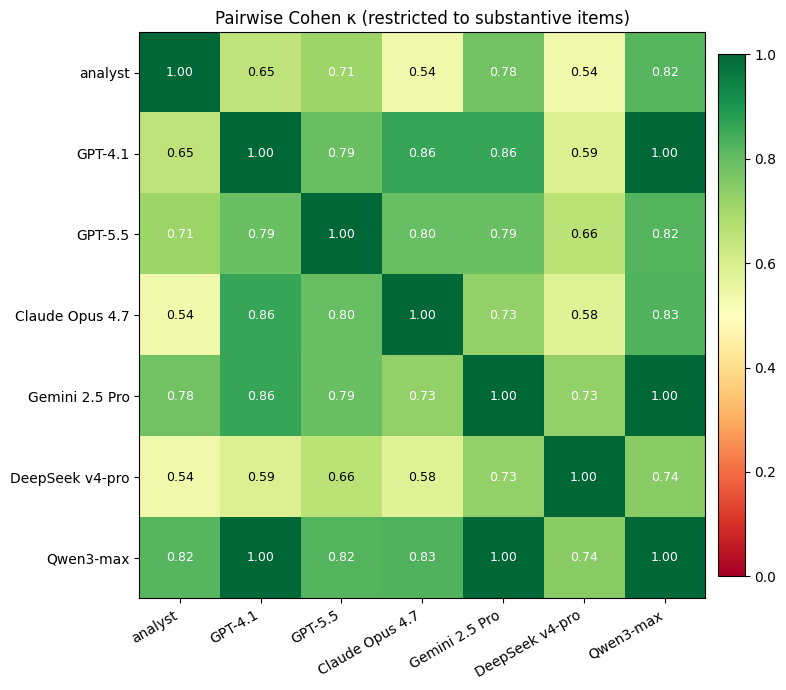

In [9]:
all_raters = ['analyst'] + [label for label, _ in MODELS]
rater_verdicts = {'analyst': [it.analyst_verdicts[0] for it in ordered]}
for label, _ in MODELS:
    eta_by_id = {it.id: it for it in evals[label].items}
    rater_verdicts[label] = [eta_by_id[it.id].model_verdict for it in ordered]

def pair_kappa(a, b):
    pairs = [(x, y) for x, y in zip(a, b) if x != 'abstain' and y != 'abstain']
    if not pairs:
        return np.nan
    n = len(pairs)
    p_obs = sum(1 for x, y in pairs if x == y) / n
    pa = {c: sum(1 for x, _ in pairs if x == c) / n for c in ('good', 'bad')}
    pb = {c: sum(1 for _, y in pairs if y == c) / n for c in ('good', 'bad')}
    pe = sum(pa[c] * pb[c] for c in ('good', 'bad'))
    if abs(1 - pe) < 1e-12:
        return np.nan
    return (p_obs - pe) / (1 - pe)

n_raters = len(all_raters)
K = np.zeros((n_raters, n_raters))
for i, r1 in enumerate(all_raters):
    for j, r2 in enumerate(all_raters):
        K[i, j] = 1.0 if i == j else pair_kappa(rater_verdicts[r1], rater_verdicts[r2])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(K, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
ax.set_xticks(range(n_raters))
ax.set_yticks(range(n_raters))
ax.set_xticklabels(all_raters, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(all_raters, fontsize=10)
for i in range(n_raters):
    for j in range(n_raters):
        if not np.isnan(K[i, j]):
            ax.text(j, i, f'{K[i, j]:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if K[i, j] > 0.7 or K[i, j] < 0.3 else 'black')
ax.set_title('Pairwise Cohen κ (restricted to substantive items)')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()

The analyst's row/column is visibly the *coolest* — the analyst is the structural outlier. The model–model block (the bottom-right 6×6) has higher mean κ than the analyst's column, consistent with the Fleiss-kappa reading in `pulmonology_2026-05-19.md`. Qwen3-max's row shows several +1.00s — artifacts of Qwen abstaining on exactly the items it would disagree with.

### 2.5 Per-item κ-contribution

Which items are doing the heavy lifting in the κ disagreement? Show each item's contribution as the number of models that disagree with the placeholder.

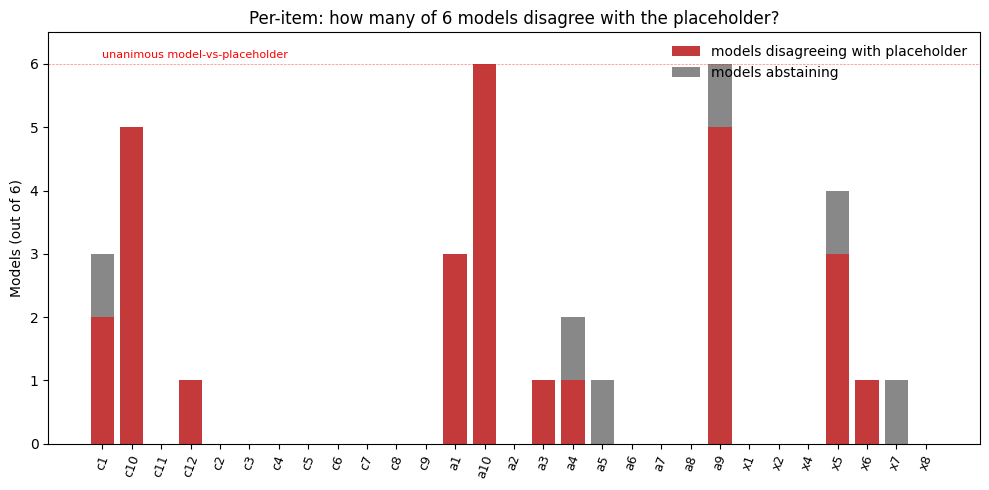

Items where ≥ 5 models disagree with the placeholder:
  a10    placeholder=good   disagree=6  abstain=0
  a9     placeholder=good   disagree=5  abstain=1
  c10    placeholder=good   disagree=5  abstain=0


In [10]:
disagreement = []
for item in ordered:
    n_disagree = 0
    n_abstain = 0
    for label, _ in MODELS:
        eta_by_id = {it.id: it for it in evals[label].items}
        v = eta_by_id[item.id].model_verdict
        if v == 'abstain':
            n_abstain += 1
        elif v != item.analyst_verdicts[0]:
            n_disagree += 1
    disagreement.append((item.id, n_disagree, n_abstain, item.analyst_verdicts[0]))

dis_df = pd.DataFrame(disagreement, columns=['item', 'n_disagree', 'n_abstain', 'analyst'])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dis_df))
ax.bar(x, dis_df['n_disagree'], color='#c43a3a', label='models disagreeing with placeholder')
ax.bar(x, dis_df['n_abstain'], bottom=dis_df['n_disagree'], color='#888888', label='models abstaining')
ax.set_xticks(x)
ax.set_xticklabels(dis_df['item'], rotation=70, fontsize=9)
ax.set_ylabel('Models (out of 6)')
ax.set_ylim(0, 6.5)
ax.axhline(6, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
ax.text(0, 6.1, 'unanimous model-vs-placeholder', color='red', fontsize=8)
ax.set_title('Per-item: how many of 6 models disagree with the placeholder?')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

print('Items where ≥ 5 models disagree with the placeholder:')
for _, row in dis_df.sort_values('n_disagree', ascending=False).iterrows():
    if row['n_disagree'] >= 5:
        print(f'  {row["item"]:5}  placeholder={row["analyst"]:5}  disagree={row["n_disagree"]}  abstain={row["n_abstain"]}')

**a9** and **a10** stand out as the unanimous disagreement set; **c10** has 5/6 (GPT-5.5 sides with the placeholder). These are exactly the items flagged in `pulmonology_2026-05-19.md` as needing explicit clinician adjudication.

## 3. What jumps out

Five visual takeaways that the CLI alone can't surface:

1. **The `bi`+`ad` backbone.** The bearer co-occurrence heatmap shows that the benchmark is *spoked around two core bearers* — almost every non-cross-cutting item has them. Side-premises are added to probe RSR. The carving is doing what the methodology intends.
2. **Qwen sits in a different quadrant.** Coverage / κ_C scatter shows Qwen3-max as the only model on the upper-left coverage tradeoff curve. None of the others use ABSTAIN meaningfully. Worth documenting in the methodology paper.
3. **a9 and a10 as a horizontal red stripe.** The item × model heatmap makes the unanimous disagreement visually unmissable in a way that a 6-column table doesn't. These are the highest-priority items for the real pulmonologist.
4. **The analyst is the rater outlier.** The pairwise κ matrix shows the analyst's row/column as the coolest band — the models agree with each other more than each agrees with the placeholder. Cuts against the "models just agree because of training-data overlap" reading.
5. **GPT-5.5 breaks c10 alone.** Subtle in the item × model heatmap as a single green cell in an otherwise red row. Worth following up — what changed between GPT-4.1 and GPT-5.5 on the elevated-BNP-in-sepsis interpretation?

These are the kinds of visual reads that motivate the next iteration of the benchmark. Once the real pulmonologist's labels arrive, regenerating this notebook will surface where the model herd was right, where the placeholder was right, and where genuine domain disagreement remains.

---

**See also**: [`experiments/results/pulmonology_2026-05-19.md`](../../experiments/results/pulmonology_2026-05-19.md) for the numeric findings doc; [`examples/pulmonary_edema/README.md`](../../examples/pulmonary_edema/README.md) for the benchmark-level context and caveats.